In [1]:
import sys
#!{sys.executable} -m pip install -q "tensorflow==2.15.1" "tensorflow-model-optimization==0.8.0" "scikit-learn==1.4.2" "pandas==2.2.2" "matplotlib==3.8.4"

!pip install tensorflow-model-optimization
print("Packages Installed")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.7/242.7 kB 4.3 MB/s eta 0:00:00
Packages Installed


In [2]:
import os
import math
import zipfile
import random
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_model_optimization as tfmot

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Python executable:", os.sys.executable)
print("TensorFlow version:", tf.__version__)
print("TF-MOT version:", tfmot.__version__)

Python executable: /usr/bin/python3
TensorFlow version: 2.20.0
TF-MOT version: 0.8.1


In [3]:
from google.colab import drive
import zipfile
import os
import shutil # Import shutil for directory operations

mount_point = '/content/drive'

# --- Robust Mounting Logic ---
if os.path.exists(mount_point):
    if os.path.isdir(mount_point):
        # Check if the directory is not empty and is NOT currently a mounted filesystem
        # (i.e., it might contain leftover files that are not part of an active mount)
        if os.listdir(mount_point) and not os.path.ismount(mount_point):
            print(f"Mount point '{mount_point}' exists and is not empty. Clearing contents before mounting...")
            for item in os.listdir(mount_point):
                item_path = os.path.join(mount_point, item)
                try:
                    if os.path.isfile(item_path) or os.path.islink(item_path):
                        os.remove(item_path)
                    elif os.path.isdir(item_path):
                        shutil.rmtree(item_path)
                except Exception as e:
                    print(f"Warning: Could not fully clean {item_path}: {e}")
            print(f"Contents of '{mount_point}' cleared.")
        elif os.path.ismount(mount_point):
            print("Google Drive is already mounted and appears clean. Proceeding with remount (if needed).")
        else: # Directory exists and is empty
            print(f"Mount point '{mount_point}' exists and is empty. Proceeding.")
    else: # /content/drive exists but is not a directory (e.g., a file or broken symlink)
        print(f"Warning: '{mount_point}' exists but is not a directory. Removing and recreating it.")
        os.remove(mount_point) # Remove the non-directory item
        os.makedirs(mount_point)
else: # /content/drive does not exist
    os.makedirs(mount_point)
    print(f"Mount point '{mount_point}' created.")

print("Attempting to mount Google Drive...")
# force_remount=True will handle cases where it was previously mounted by Colab
# and will re-attempt to mount even if the directory was empty before.
drive.mount(mount_point, force_remount=True)
# --- End of Robust Mounting Logic ---

zip_path = '/content/drive/MyDrive/KaggleGazeCapture/eye_gaze_train_lsr.zip'
extract_path = '/content/eye_gaze_train_lsr/'

# Check if the extract_path does not exist or is empty
if not os.path.exists(extract_path) or not os.listdir(extract_path):
    print(f"Dataset not found locally or is empty. Extracting from Drive...")
    os.makedirs(extract_path, exist_ok=True)
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("Extraction complete!")
    # Verification after extraction
    if os.path.exists(extract_path) and os.listdir(extract_path):
        print(f"Verification: '{extract_path}' exists and contains {len(os.listdir(extract_path))} items.")
    else:
        print(f"Verification: Extraction seems to have failed. '{extract_path}' is either missing or empty.")
else:
    print("Dataset directory already exists and contains data.")
    # Verification if directory already exists and contains data
    if os.path.exists(extract_path) and os.listdir(extract_path):
        print(f"Verification: '{extract_path}' already exists and contains {len(os.listdir(extract_path))} items.")
    else:
        print(f"Verification: '{extract_path}' exists but is empty. This condition should not be reached with the updated logic, but checking just in case.")

Mount point '/content/drive' created.
Attempting to mount Google Drive...
Mounted at /content/drive
Dataset not found locally or is empty. Extracting from Drive...
Extraction complete!
Verification: '/content/eye_gaze_train_lsr/' exists and contains 2 items.


In [4]:
IMAGE_SIZE = 64
BATCH_SIZE = 32
ALPHA = 0.05

train_dir = extract_path + '/eye_gaze_train_lsr/train/'
test_dir = extract_path + '/eye_gaze_train_lsr/test/'


train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    shuffle=True,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    color_mode='grayscale',
    interpolation='lanczos3',
    batch_size=None # Load unbatched images initially
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    shuffle=False,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    color_mode='grayscale',
    interpolation='lanczos3',
    batch_size=None # Load unbatched images initially
)

Found 173886 files belonging to 3 classes.
Found 32233 files belonging to 3 classes.


In [5]:
# 1. Check tensor shapes and data types
print("--- Dataset Element Specifications ---")
print("Train Dataset Spec:", train_dataset.element_spec)
print("Test Dataset Spec: ", test_dataset.element_spec)

# 2. Inspect class names and total counts
class_names = train_dataset.class_names
print(f"\n--- Class Information ---")
print(f"Total Classes ({len(class_names)}): {class_names}")

--- Dataset Element Specifications ---
Train Dataset Spec: (TensorSpec(shape=(64, 64, 1), dtype=tf.float32, name=None), TensorSpec(shape=(), dtype=tf.int32, name=None))
Test Dataset Spec:  (TensorSpec(shape=(64, 64, 1), dtype=tf.float32, name=None), TensorSpec(shape=(), dtype=tf.int32, name=None))

--- Class Information ---
Total Classes (3): ['left', 'right', 'straight']


In [7]:
# Function to count samples per class in a dataset
def count_samples_per_class(dataset, class_names):
    class_counts = np.zeros(len(class_names), dtype=int)
    for _, labels in dataset:
        unique_labels, counts = np.unique(labels.numpy(), return_counts=True)
        for label, count in zip(unique_labels, counts):
            class_counts[label] += count

    print("\n--- Sample Counts per Class ---")
    for i, count in enumerate(class_counts):
        print(f"Class '{class_names[i]}': {count} samples")
    return class_counts


print("\n--- Training Dataset Class Counts ---")
train_class_counts = count_samples_per_class(train_dataset, class_names)

print("\n--- Test Dataset Class Counts ---")
test_class_counts = count_samples_per_class(test_dataset, class_names)


--- Training Dataset Class Counts ---

--- Sample Counts per Class ---
Class 'left': 49839 samples
Class 'right': 53019 samples
Class 'straight': 71028 samples

--- Test Dataset Class Counts ---

--- Sample Counts per Class ---
Class 'left': 8923 samples
Class 'right': 9529 samples
Class 'straight': 13781 samples


In [8]:
INPUT_SHAPE = (IMAGE_SIZE, IMAGE_SIZE, 1)

def augment_image(image, label):
    # This function now receives a single image (3-D tensor: H, W, C)
    resize_factor = tf.random.uniform([], minval=1.0, maxval=1.2, dtype=tf.float32)
    new_height = tf.cast(resize_factor * INPUT_SHAPE[0], tf.int32)
    new_width = tf.cast(resize_factor * INPUT_SHAPE[1], tf.int32)

    # tf.image.resize_with_crop_or_pad now correctly receives 3-D images
    image = tf.image.resize_with_crop_or_pad(image, new_height, new_width)

    # tf.image.random_crop now correctly receives 3-D images
    image = tf.image.random_crop(image, size=INPUT_SHAPE)

    # tf.image.random_brightness supports N-D images where N >= 3, so it works directly on 3-D
    image = tf.image.random_brightness(image, max_delta=0.2)
    return image, label

def normalize_images(image, label):
    # This function now receives a single image (3-D tensor: H, W, C)
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

AUTOTUNE = tf.data.AUTOTUNE # Keep AUTOTUNE defined here

### Preparing separate training and validation datasets

Since `validation_split` does not work directly on `tf.data.Dataset` objects, we need to manually split our `train_dataset` into separate training and validation datasets. We'll use 80% for training and 20% for validation, matching the `validation_split=0.2` you intended.

Now, let's apply the augmentation to the training dataset. It's important to apply augmentation only to the training set, not the validation or test sets, to avoid data leakage and ensure a realistic evaluation of the model's performance on unseen data.

In [9]:
# Determine the total number of samples from the unbatched training dataset
DATASET_SIZE = tf.data.experimental.cardinality(train_dataset).numpy()
val_size_samples = int(0.2 * DATASET_SIZE) # 20% for validation, in terms of samples

# Split the unbatched train_dataset into unbatched training and validation sets
val_ds_unbatched = train_dataset.take(val_size_samples)
train_ds_unbatched = train_dataset.skip(val_size_samples)

# Apply augmentation to the UNBATCHED training dataset
train_ds_aug = train_ds_unbatched.map(augment_image, num_parallel_calls=AUTOTUNE)

# Apply normalization to all datasets (augmented training, validation, and test)
train_ds = train_ds_aug.map(normalize_images, num_parallel_calls=AUTOTUNE)
val_ds = val_ds_unbatched.map(normalize_images, num_parallel_calls=AUTOTUNE)
test_ds = test_dataset.map(normalize_images, num_parallel_calls=AUTOTUNE) # Renamed for consistency

# Batch and prefetch all final datasets for efficient training
train_ds = train_ds.batch(BATCH_SIZE).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(buffer_size=AUTOTUNE)

print(f"Original unbatched train_dataset samples: {DATASET_SIZE}")
print(f"Validation samples: {tf.data.experimental.cardinality(val_ds_unbatched).numpy()}")
print(f"Augmented training samples: {tf.data.experimental.cardinality(train_ds_unbatched).numpy()}")

print(f"\nFinal batched training_dataset batches: {tf.data.experimental.cardinality(train_ds).numpy()}")
print(f"Final batched validation_dataset batches: {tf.data.experimental.cardinality(val_ds).numpy()}")
print(f"Final batched test_dataset batches: {tf.data.experimental.cardinality(test_ds).numpy()}")

Original unbatched train_dataset samples: 173886
Validation samples: 34777
Augmented training samples: 139109

Final batched training_dataset batches: 4348
Final batched validation_dataset batches: 1087
Final batched test_dataset batches: 1008


In [10]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Input

# Get the number of classes from class_names
num_classes = len(class_names)

# Create the base MobileNetV2 model with pre-trained weights
# include_top=False to remove the classification layer of the pre-trained model
# input_shape should match IMAGE_SIZE and color_mode (grayscale means 1 channel)
base_model = MobileNetV2(
    input_shape=(IMAGE_SIZE, IMAGE_SIZE, 1),
    alpha=ALPHA,
    include_top=False,
    weights=None,
)

inputs = Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 1))
x = base_model(inputs)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.1)(x)
outputs = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=inputs, outputs=outputs, name="eye_gaze_model_lsr_64px")
model.build((None, IMAGE_SIZE, IMAGE_SIZE, 1))


model.summary()


Model: "eye_gaze_model_lsr_64px"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 64, 64, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_0.05_64             │ (None, 2, 2, 1280)     │        52,176 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 56,019 (218.82 KB)

 Trainable params: 50,067 (195.57 KB)

 Non-trainable params: 5,952 (23.25 KB)

In [11]:
model.compile(
    optimizer="adam",
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True
    )
]


# Train the model
# You might want to adjust epochs based on dataset size and convergence
history = model.fit(
    train_ds, # Use the new training dataset
    epochs=40,
    validation_data=val_ds, # Pass the separate validation dataset
    callbacks=callbacks,
    verbose=1
)

Epoch 1/40
4348/4348 ━━━━━━━━━━━━━━━━━━━━ 327s 57ms/step - accuracy: 0.4622 - loss: 1.0234 - val_accuracy: 0.4644 - val_loss: 1.0378
Epoch 2/40
4348/4348 ━━━━━━━━━━━━━━━━━━━━ 228s 47ms/step - accuracy: 0.6279 - loss: 0.8099 - val_accuracy: 0.6162 - val_loss: 0.8952
Epoch 3/40
4348/4348 ━━━━━━━━━━━━━━━━━━━━ 220s 45ms/step - accuracy: 0.6687 - loss: 0.7396 - val_accuracy: 0.6644 - val_loss: 0.7609
Epoch 4/40
4348/4348 ━━━━━━━━━━━━━━━━━━━━ 223s 46ms/step - accuracy: 0.6941 - loss: 0.6855 - val_accuracy: 0.7061 - val_loss: 0.6880
Epoch 5/40
4348/4348 ━━━━━━━━━━━━━━━━━━━━ 239s 49ms/step - accuracy: 0.7218 - loss: 0.6266 - val_accuracy: 0.7345 - val_loss: 0.6149
Epoch 6/40
4348/4348 ━━━━━━━━━━━━━━━━━━━━ 247s 46ms/step - accuracy: 0.7439 - loss: 0.5827 - val_accuracy: 0.7565 - val_loss: 0.5574
Epoch 7/40
4348/4348 ━━━━━━━━━━━━━━━━━━━━ 257s 45ms/step - accuracy: 0.7585 - loss: 0.5545 - val_accuracy: 0.7306 - val_loss: 0.6362
Epoch 8/40
4348/4348 ━━━━━━━━━━━━━━━━━━━━ 243s 51ms/step - accuracy: 

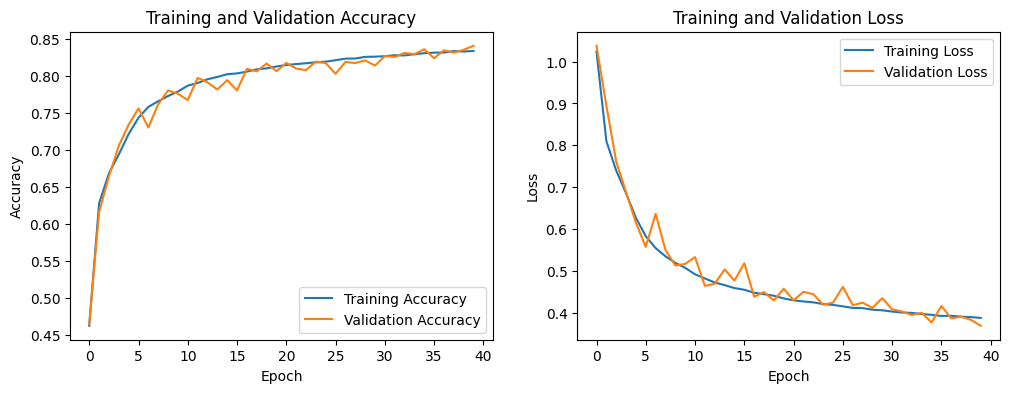

In [12]:
import matplotlib.pyplot as plt

# Plot training history (accuracy and loss)
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.show()

In [13]:
import numpy as np

# Extract all images and labels from the test_dataset
all_test_images = []
all_test_labels = []

for images, labels in test_ds:
    all_test_images.append(images.numpy())
    all_test_labels.append(labels.numpy())

X_test = np.vstack(all_test_images)
y_test = np.concatenate(all_test_labels)

print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_test: (32233, 64, 64, 1)
Shape of y_test: (32233,)


1008/1008 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step

Test Accuracy: 0.7002

Classification Report:
              precision    recall  f1-score   support

        left     0.7925    0.6285    0.7010      8923
       right     0.7166    0.7141    0.7154      9529
    straight     0.6484    0.7369    0.6898     13781

    accuracy                         0.7002     32233
   macro avg     0.7192    0.6932    0.7021     32233
weighted avg     0.7085    0.7002    0.7005     32233



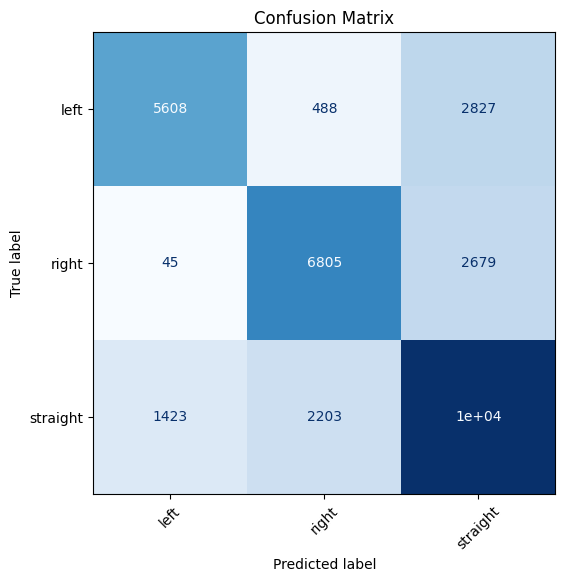

In [14]:
# X_test will now be correctly shaped, so no explicit reshape is needed here.
# Make predictions on the extracted test data
probs = model.predict(X_test, verbose=1)
preds = np.argmax(probs, axis=1)

# Calculate accuracy
test_acc = accuracy_score(y_test, preds)

print(f"\nTest Accuracy: {test_acc:.4f}\n")

# Generate and print classification report
print("Classification Report:")
print(classification_report(y_test, preds, target_names=class_names, digits=4))

# Plot confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, preds),
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix")
plt.show()

In [15]:
import os

# Define the directory to save the model in Google Drive
save_dir = '/content/drive/MyDrive/saved_models'
model_name = 'eye_gaze_lsr_mobilenetv2_64px_alpha005.keras'
model_path = os.path.join(save_dir, model_name)

# Create the directory if it doesn't exist
os.makedirs(save_dir, exist_ok=True)

# Save the entire model in the TensorFlow SavedModel format
# This includes: the architecture, the weights, and the training configuration (optimizer, loss, metrics)
# For TensorFlow SavedModel format in Keras 3, use model.export()
model.save(model_path)

print(f"Model saved successfully to: {model_path}")

Model saved successfully to: /content/drive/MyDrive/saved_models/eye_gaze_lsr_mobilenetv2_64px_alpha005.keras


In [16]:
from pathlib import Path

def make_representative_data_gen(batched_dataset, max_samples=7000):
    representative_images = []
    for batch_images, _ in batched_dataset.take(max_samples // BATCH_SIZE + 1):
        for image in batch_images:
            if len(representative_images) < max_samples:
                representative_images.append(image.numpy())
            else:
                break
        if len(representative_images) >= max_samples:
            break

    def generator():
        for img in representative_images:
            sample = np.expand_dims(img, axis=0).astype(np.float32)  # add batch dim -> (1,H,W,C)
            yield [sample]

    return generator

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]  # no EXPERIMENTAL_SPARSITY - nothing pruned here
converter.representative_dataset = make_representative_data_gen(train_ds)
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

tflite_model = converter.convert()
tflite_path = Path(f"{save_dir}/eye_gaze_lsr_mobilenetv2_64px_alpha005_ptq.tflite")
tflite_path.write_bytes(tflite_model)
print(f"Saved {tflite_path.name}: {tflite_path.stat().st_size / 1024:.2f} KB")

Saved artifact at '/tmp/tmp32e2nbd3'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 64, 64, 1), dtype=tf.float32, name='keras_tensor_156')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  137451041396816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137450548224528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137450548226448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137450548226064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137450548224144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137450548224336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137450548226640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137450548227408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137450548227024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137450548224912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137450548226

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


Saved eye_gaze_lsr_mobilenetv2_64px_alpha005_ptq.tflite: 168.39 KB


You can then load this H5 file using `tf.keras.models.load_model()` and proceed with quantization-aware training or post-training quantization.